## Analitika kitabxanalarının yüklənməsi

#### İstifadə olunacaq numpy, pandas, matplotlib və seaborn kitabxanalarını gətirin

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Datasetin Yüklənməsi

#### Dataseti yükləyin

In [272]:
df = pd.read_csv(r'C:\Users\User Windows 10 Pro\Desktop\MDA37-handex\Final\netflix daily top 10.csv', delimiter = ',', encoding='UTF8')

## Dataset Məlumatları

#### Datasetlə tanış olun və ilk 10 dəyərinə göz gəzdirin

In [273]:
df.head(10)

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
0,2020-04-01,1,1,1,"Tiger King: Murder, Mayhem …",TV Show,Yes,"Mar 20, 2020",9,90
1,2020-04-01,2,2,-,Ozark,TV Show,Yes,"Jul 21, 2017",5,45
2,2020-04-01,3,3,2,All American,TV Show,NaN,"Mar 28, 2019",9,76
3,2020-04-01,4,4,-,Blood Father,Movie,NaN,"Mar 26, 2020",5,30
4,2020-04-01,5,5,4,The Platform,Movie,Yes,"Mar 20, 2020",9,55
5,2020-04-01,6,6,-,Car Masters: Rust to Riches,TV Show,Yes,"Sep 14, 2018",4,14
6,2020-04-01,7,10,-,Unorthodox,TV Show,Yes,"Mar 26, 2020",2,5
7,2020-04-01,8,7,5,Love is Blind,TV Show,Yes,"Feb 13, 2020",9,40
8,2020-04-01,9,8,-,Badland,Movie,NaN,"Mar 26, 2020",4,11
9,2020-04-01,10,9,-,Uncorked,Movie,Yes,"Mar 27, 2020",4,15


#### Dataset haqqında məlumat əldə edə biləcəyiniz kodları yazın. Dataset neçə sətrdən ibarətdir, hansı sütunları var, sütunların tipləri nələrdir?

In [6]:
df.info()
#setr sayi-7100
#sutunlar column yazilan yerin altinda gosterilir
#sutun tipleri - object ve int

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7100 entries, 0 to 7099
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   As of                 7100 non-null   object
 1   Rank                  7100 non-null   int64 
 2   Year to Date Rank     7100 non-null   object
 3   Last Week Rank        7100 non-null   object
 4   Title                 7100 non-null   object
 5   Type                  7100 non-null   object
 6   Netflix Exclusive     4599 non-null   object
 7   Netflix Release Date  7100 non-null   object
 8   Days In Top 10        7100 non-null   int64 
 9   Viewership Score      7100 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 554.8+ KB


In [7]:
#diger kodlar 
df.columns

Index(['As of', 'Rank', 'Year to Date Rank', 'Last Week Rank', 'Title', 'Type',
       'Netflix Exclusive', 'Netflix Release Date', 'Days In Top 10',
       'Viewership Score'],
      dtype='object')

In [8]:
df.shape

(7100, 10)

## Data Wrangling

#### Datanın sütunları ilə tanış olun. Onlar hansı data tiplərindədir? Bütün sütunların data tipləri uyğundur?

In [ ]:
#bezi sutunlarin tipleri deyismelidir.

#### Düzgün data tipində olmayan müvafiq data tiplərinə keçirin

In [274]:
df['As of'] = pd.to_datetime(df['As of'], errors = 'coerce')

In [275]:
df['Netflix Release Date'] = pd.to_datetime(df['Netflix Release Date'], errors = 'coerce')

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7100 entries, 0 to 7099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   As of                 7100 non-null   datetime64[ns]
 1   Rank                  7100 non-null   int64         
 2   Year to Date Rank     7100 non-null   object        
 3   Last Week Rank        7100 non-null   object        
 4   Title                 7100 non-null   object        
 5   Type                  7100 non-null   object        
 6   Netflix Exclusive     4599 non-null   object        
 7   Netflix Release Date  7100 non-null   datetime64[ns]
 8   Days In Top 10        7100 non-null   int64         
 9   Viewership Score      7100 non-null   int64         
 10  Month                 7100 non-null   object        
dtypes: datetime64[ns](2), int64(3), object(6)
memory usage: 610.3+ KB


#### Hansı sütunlarda boş sətrlər var? Hansı sütunlarda neçə boş sətr var?

In [11]:

df.isnull().mean()*100

As of                    0.000000
Rank                     0.000000
Year to Date Rank        0.000000
Last Week Rank           0.000000
Title                    0.000000
Type                     0.000000
Netflix Exclusive       35.225352
Netflix Release Date     0.000000
Days In Top 10           0.000000
Viewership Score         0.000000
dtype: float64

In [16]:
df.isnull().sum().sum()

2501

#### Boş sətrlər olan sütunda olan bütün boş məlumatları "No" yazısı ilə doldurun

In [293]:
df=df.fillna(value='No')

In [20]:
df.isnull().mean()*100

As of                   0.0
Rank                    0.0
Year to Date Rank       0.0
Last Week Rank          0.0
Title                   0.0
Type                    0.0
Netflix Exclusive       0.0
Netflix Release Date    0.0
Days In Top 10          0.0
Viewership Score        0.0
dtype: float64

## Analysis

#### Datada film tiplərinə görə paylanmanı göstərmək üçün pie chart-dan istifadə edin

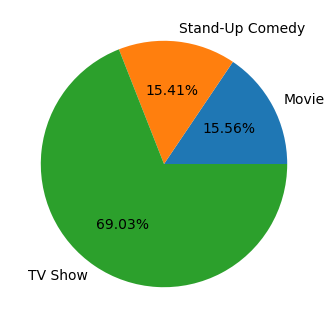

In [33]:
plt.figure(figsize=(4,4))
plt.pie(df.groupby('Type')['Viewership Score'].mean().tail(3),labels=df.groupby('Type')['Viewership Score'].mean().tail(3).index,autopct='%1.2f%%')
plt.show()

#### Ən çox hansı filmlər ilk 10 film arasına girib?

In [47]:
df[df['Rank']<=10]['Title'].value_counts().head(10)

Title
Cocomelon               428
Ozark                    85
Cobra Kai                81
Manifest                 80
The Queenâs Gambit     73
Outer Banks              72
Squid Game               66
All American             58
Bridgerton               58
Lucifer                  56
Name: count, dtype: int64

#### İstifadəçi reytinqlərinə görə ən yüksək 10 film hansıdır? Nəticəni vizuallaşdırın

In [57]:
df.groupby('Title')['Viewership Score'].mean().head(10)

Title
#Alive                 22.333333
#blackAF               22.875000
(Un)Well               14.000000
13 Reasons Why        101.090909
17 Again               18.857143
1BR                    10.000000
2 Hearts               35.090909
21 Jump Street         26.333333
30 Minutes or Less     10.200000
365 Days              125.285714
Name: Viewership Score, dtype: float64

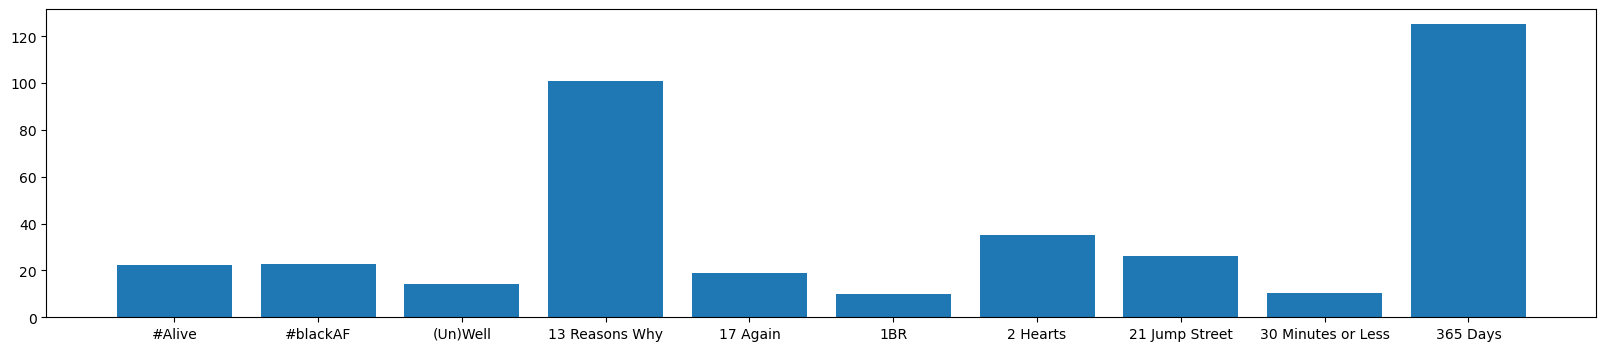

In [280]:
plt.figure(figsize=(20,4))
plt.bar(df.groupby('Title')['Viewership Score'].mean().head(10).index,df.groupby('Title')['Viewership Score'].mean().head(10))
plt.show()

In [72]:
df1=df.groupby('Title')['Viewership Score'].mean().head(10).reset_index()

C:\Users\User Windows 10 Pro\AppData\Local\Temp\ipykernel_16900\2602275233.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  dff=sns.barplot(y='Viewership Score',x='Title',data=df1,ci=None,estimator=np.mean)


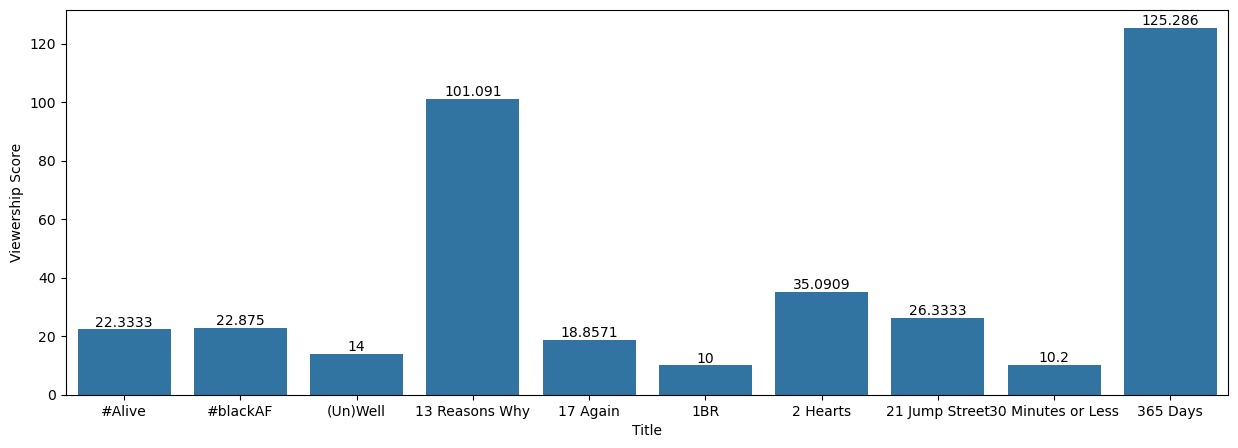

In [97]:
plt.figure(figsize=(15,5))
dff=sns.barplot(y='Viewership Score',x='Title',data=df1,ci=None,estimator=np.mean)
for container in dff.containers:
    dff.bar_label(container)
plt.show()

#### Ən çox birinci yerdə qalan filmi öyrənmək istəyirəm

In [101]:
df[df['Rank']==1]['Title'].value_counts().head(1)  #idxmax()

Title
Cobra Kai    27
Name: count, dtype: int64

#### Neçə fərqli gün üçün aparılıb bu ölçümlər? Yəni neçə fərqli gün üçün top 10 film göstərilib?

In [106]:
df['As of'].nunique()

710

#### Netflix Exclusive filmlər daha yüksək reytinqə sahibdir, yoxsa digərləri?

In [133]:
pd.pivot_table(df,index='Netflix Exclusive',values='Viewership Score',aggfunc='mean')

,Viewership Score
Netflix Exclusive,
No,185.542583
Yes,88.664492


#### Mən TV Show və Movie lər üçün aylıq trendi görmək istəyirəm.

In [292]:
df['Netflix_Month']=df['As of'].dt.month_name()

In [221]:
df2=df[(df['Type']=='TV Show') | (df['Type']=='Movie')]

In [222]:
df2.groupby(['Netflix_Month','Type','Title'])['Days In Top 10'].mean().groupby(['Netflix_Month','Type']).head(3)

Netflix_Month  Type     Title                 
April          Movie    American Me                2.0
                        Angel Has Fallen           6.5
                        Bad Trip                   7.0
               TV Show  #blackAF                   4.5
                        Absurd Planet              2.5
                                                  ... 
September      Movie    Afterlife of the Party     4.5
                        An Unfinished Life         4.0
               TV Show  All American              65.0
                        Ancient Aliens             1.5
                        Away                      10.5
Name: Days In Top 10, Length: 72, dtype: float64

#### Mən filmin Netflix-də yayınlanma tarixi ilə hər hansı bir korrelyasiyaya sahib olub olmadığını öyrənmək istəyirəm. Bunu həm düsturla, həm də vizualizasiya ilə göstərməlisiniz

In [210]:
df['Viewership Score'].corr(df['Netflix Release Date'])*100

-3.5927466376779162

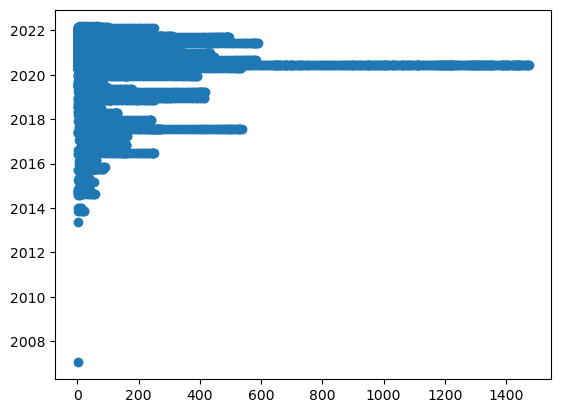

In [211]:
plt.scatter(df['Viewership Score'], df['Netflix Release Date'])

#### Yuxarıdakı xətaya əsasən, aşağıda təkcə illərə görə yeni bir korrelyasiya əmsalı hesablayın

In [291]:
df['Netflix_Year']=df['As of'].dt.year

In [219]:
df['Viewership Score'].corr(df['Netflix_Year'])*100

19.162479388127164

#### Aylara görə ən məşhur Filmlər hansı olub?

In [290]:
df['month']=df['As of'].dt.month_name()

In [229]:
df.groupby(['month','Title'])['Rank'].count().groupby('month').head(1)

month      Title                         
April      #blackAF                           8
August     (Un)Well                           6
December   A Boy Called Christmas             3
February   Age of Samurai: Battle for …       4
January    17 Again                           7
July       365 Days                           5
June       13 Reasons Why                    22
March      A Week Away                        4
May        All Day and a Night                6
November   21 Jump Street                     9
October    A Babysitterâs Guide to Mon…     3
September  #Alive                             6
Name: Rank, dtype: int64

#### 1/2/3/4 rübdə ən yüksək izləyici reytinqi olan 5 film hansı olub?

In [295]:
df['quarter']=df['As of'].dt.quarter

In [307]:
df.groupby(['quarter','Title'])['Viewership Score'].mean().groupby(['quarter','Title']).head(5).reset_index()

,quarter,Title,Viewership Score
0,1,17 Again,18.857143
1,1,30 Minutes or Less,10.200000
2,1,A Week Away,9.250000
3,1,After We Fell,18.000000
4,1,Against the Ice,3.000000
...,...,...,...
736,4,Wentworth,6.250000
737,4,White Christmas,1.000000
738,4,"Yes, God, Yes",8.750000
739,4,Yogi Bear,5.250000


#### Yeni bir dashboard yaradın (15,15 ölçüsündə). Ən önəmli gördüyünüz 4 ədəd vizualı bu dashboard-da göstərin

C:\Users\User Windows 10 Pro\AppData\Local\Temp\ipykernel_16900\3945230686.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  dff=sns.barplot(y='Viewership Score',x='Title',data=df1,ci=None,estimator=np.mean)
C:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 153 (\x99) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


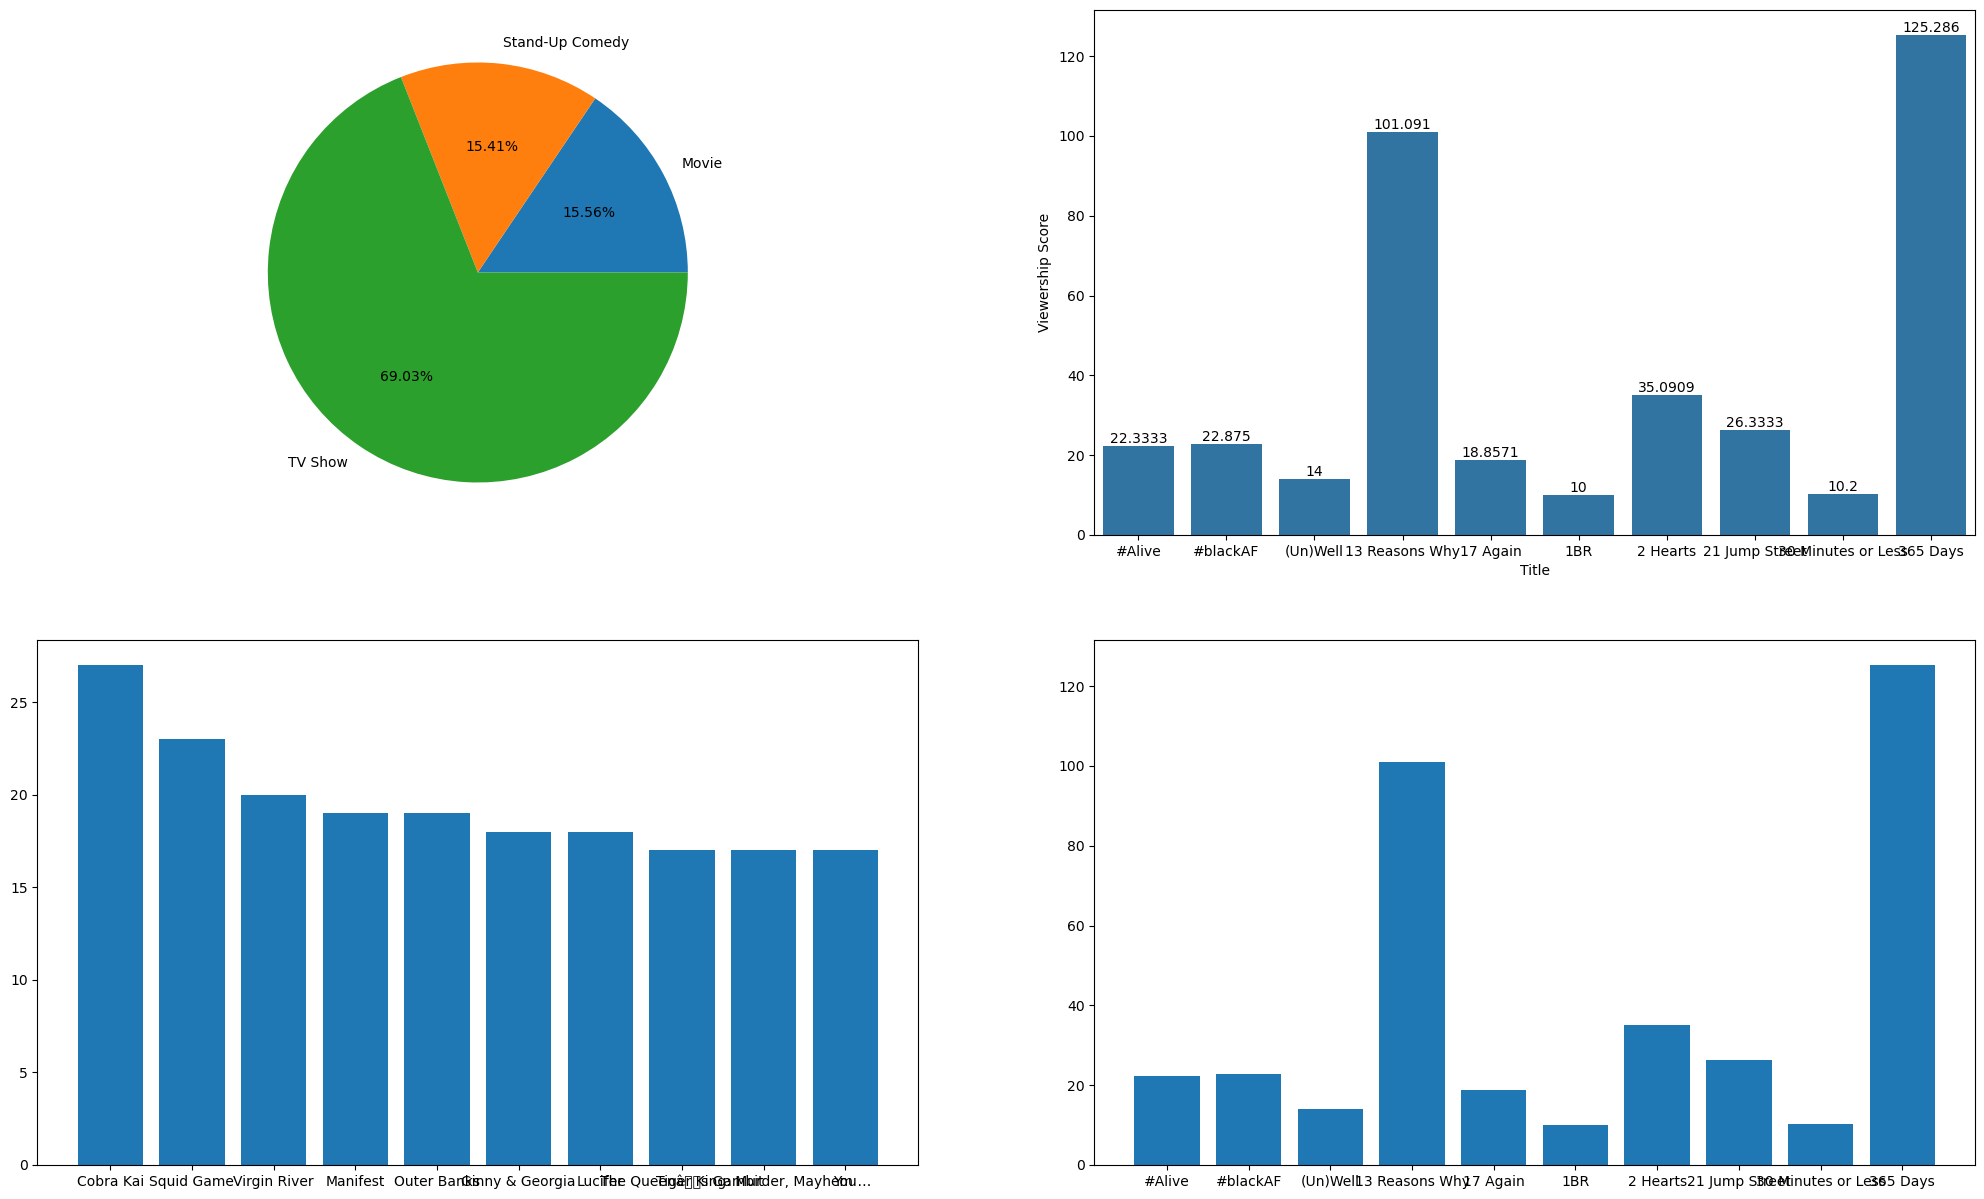

In [288]:
plt.figure(figsize=(25,15))

plt.subplot(2,2,1)
plt.pie(df.groupby('Type')['Viewership Score'].mean().tail(3),labels=df.groupby('Type')['Viewership Score'].mean().tail(3).index,autopct='%1.2f%%')

plt.subplot(2,2,2)
dff=sns.barplot(y='Viewership Score',x='Title',data=df1,ci=None,estimator=np.mean)
for container in dff.containers:
    dff.bar_label(container)

plt.subplot(2,2,3)
plt.bar(df[df['Rank']==1]['Title'].value_counts().head(10).index,df[df['Rank']==1]['Title'].value_counts().head(10))

plt.subplot(2,2,4)
plt.bar(df.groupby('Title')['Viewership Score'].mean().head(10).index,df.groupby('Title')['Viewership Score'].mean().head(10))

plt.show()